训练普通网络（输出层 ReLU + 偏置初始化）...
训练残差网络（输出层 ReLU + 偏置初始化）...


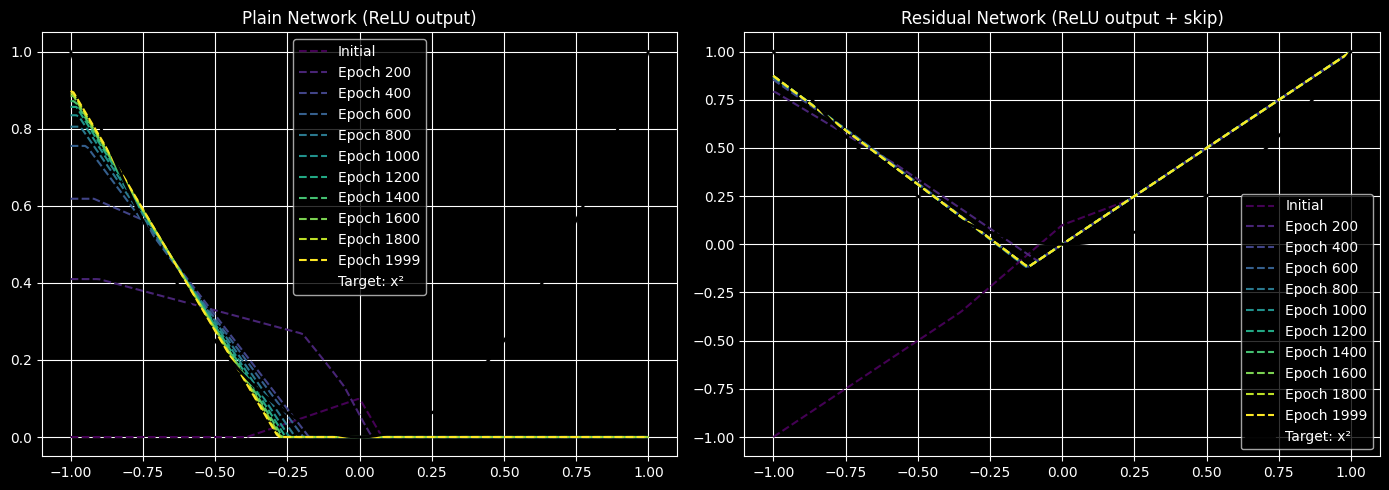

最终损失：普通网络 0.102758，残差网络 0.018423


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ======================= 生成数据 =======================
np.random.seed(42)
x = np.linspace(-1, 1, 200).reshape(-1, 1)
y_true = x ** 2

def train_with_snapshots(net_type='plain', hidden_size=10, lr=0.05, epochs=2000, snap_interval=200, use_leaky=False):
    """
    net_type: 'plain' 或 'residual'
    use_leaky: 若为 True，输出层使用 Leaky ReLU (alpha=0.01)
    """
    # 参数初始化（输出层偏置设为正数，避免全负）
    W1 = np.random.randn(1, hidden_size) * 0.5
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.5
    b2 = np.ones((1, 1)) * 0.1          # 使初始 z2 为正

    loss_history = []
    snapshots = []
    m = x.shape[0]

    for epoch in range(epochs):
        # 隐藏层
        z1 = x @ W1 + b1
        a1 = np.maximum(0, z1)

        # 输出层（支持普通 ReLU 或 Leaky ReLU）
        z2 = a1 @ W2 + b2
        if use_leaky:
            out = np.where(z2 > 0, z2, 0.01 * z2)   # Leaky ReLU
        else:
            out = np.maximum(0, z2)

        if net_type == 'plain':
            y_pred = out
        else:
            y_pred = out + x

        loss = np.mean((y_pred - y_true) ** 2)
        loss_history.append(loss)

        if epoch % snap_interval == 0 or epoch == epochs - 1:
            snapshots.append((epoch, y_pred.copy()))

        # ---------- 反向传播 ----------
        dL_dy = 2 * (y_pred - y_true) / m

        if net_type == 'plain':
            dL_dout = dL_dy
        else:
            dL_dout = dL_dy

        # 输出层激活函数梯度
        if use_leaky:
            dL_dz2 = dL_dout * (np.where(z2 > 0, 1, 0.01))
        else:
            dL_dz2 = dL_dout * (z2 > 0)

        dL_dW2 = a1.T @ dL_dz2
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

        # 隐藏层
        dL_da1 = dL_dz2 @ W2.T
        dL_dz1 = dL_da1 * (z1 > 0)
        dL_dW1 = x.T @ dL_dz1
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

        # 更新
        W2 -= lr * dL_dW2
        b2 -= lr * dL_db2
        W1 -= lr * dL_dW1
        b1 -= lr * dL_db1

    return loss_history, snapshots

# ======================= 训练 =======================
print("训练普通网络（输出层 ReLU + 偏置初始化）...")
loss_plain, snaps_plain = train_with_snapshots('plain', use_leaky=False)
print("训练残差网络（输出层 ReLU + 偏置初始化）...")
loss_res, snaps_res = train_with_snapshots('residual', use_leaky=False)

# 绘制
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(snaps_plain)))

for i, (epoch, pred) in enumerate(snaps_plain):
    ax = axes[0]
    label = f'Epoch {epoch}' if i > 0 else 'Initial'
    ax.plot(x, pred, '--', color=colors[i], linewidth=1.5, label=label)
axes[0].plot(x, y_true, 'k-', linewidth=2, label='Target: x²')
axes[0].set_title('Plain Network (ReLU output)')
axes[0].legend()
axes[0].grid(True)

for i, (epoch, pred) in enumerate(snaps_res):
    ax = axes[1]
    label = f'Epoch {epoch}' if i > 0 else 'Initial'
    ax.plot(x, pred, '--', color=colors[i], linewidth=1.5, label=label)
axes[1].plot(x, y_true, 'k-', linewidth=2, label='Target: x²')
axes[1].set_title('Residual Network (ReLU output + skip)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"最终损失：普通网络 {loss_plain[-1]:.6f}，残差网络 {loss_res[-1]:.6f}")